In [2]:
from dataMaker import DataHandler
import plotter
import dataLoader

import torch
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

### Data Paths

In [3]:
TRAIN_DATA_PATH = '/workspace/data/cv_project/grid_data_train.h5'
VAL_DATA_PATH = '/workspace/data/cv_project/grid_data_val.h5'
MAT_DATA_PATH = '/workspace/data/cv_project/grid_data.mat'
MAT_NOISE_DATA_PATH = '/workspace/data/cv_project/noise_only_data.mat'

### Generate Spectrogams

Here we generate spectrograms from the .mat files which contain the results of the [KRAKEN](https://oalib-acoustics.org/models-and-software/normal-modes/) simulation.

In [3]:
# Load simulated data into data object
handler = DataHandler(path=MAT_DATA_PATH, noise_only_path=MAT_NOISE_DATA_PATH)

# Make each audio waveform have mean=0 and var=1
handler.normalize_wav()

# Create spectrograms
handler.create_spectrograms(rand_shift=True, nperseg=60, noverlap=52, nfft=736, verbose=True)

# Save data
handler.save_split_h5(train_path=TRAIN_DATA_PATH, val_path=VAL_DATA_PATH, train_size=0.8, shuffle=True)

del handler

  0%|          | 0/40312 [00:00<?, ?it/s]

### Visualize Data

Load the validation data.

In [4]:
X, y = dataLoader.load_h5(VAL_DATA_PATH)

Plot the different classes

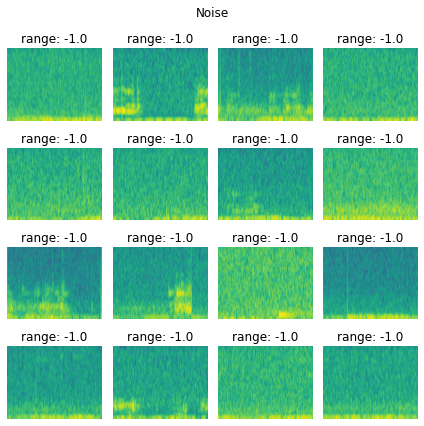

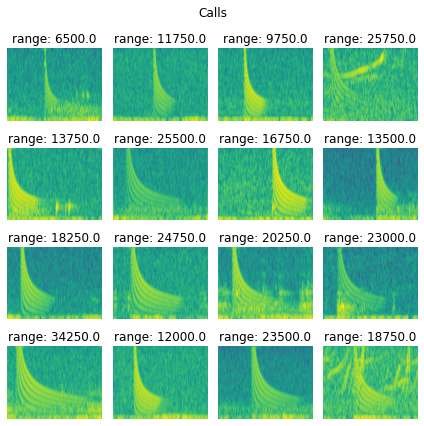

In [5]:
# Plot examples from noise class
plotter.plot_grid(X[np.where(y[:,4] == 0)], y[np.where(y[:,4] == 0),0].squeeze(), label_text="range", title="Noise", dim=(4,4))

# Plot examples from call class
plotter.plot_grid(X[np.where(y[:,4] == 1)], y[np.where(y[:,4] == 1),0].squeeze(), label_text="range", title="Calls", dim=(4,4))

### Get Image Statistics

In [ ]:
dataset = dataLoader.Gunshot(dir_path=TRAIN_DATA_PATH)
dataloader = data.DataLoader(dataset, batch_size=32, drop_last=False, shuffle=True)

In [5]:
from tqdm.notebook import tqdm
count = 0
for inputs, labels in tqdm(dataloader):
    count += len(inputs)
print(count)

NameError: name 'dataloader' is not defined

In [1]:
a = next(iter(dl))
b, c = a[0], a[1]

NameError: name 'dl' is not defined

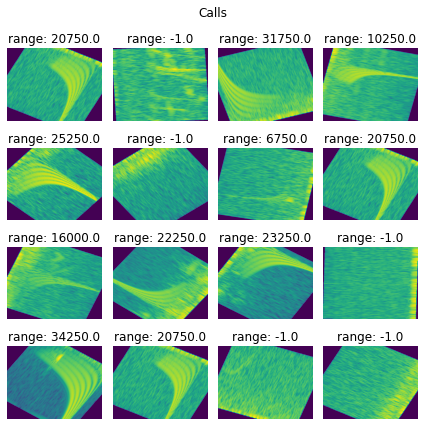

In [17]:
plotter.plot_grid(b.numpy(), c[:,0].numpy(), label_text="range", title="Calls", dim=(4,4))